# Phase 3 — Real data

Phase 2 proved the model learns. Everything from here is about feeding it real text.

The corpus is [harsh19/Shakespearizing-Modern-English](https://github.com/harsh19/Shakespearizing-Modern-English): Shakespeare's lines aligned sentence-by-sentence with SparkNotes' *No Fear Shakespeare* rewrites. Already tokenised, so whitespace splitting is enough.

In [1]:
import os
import sys

for candidate in (os.getcwd(), os.path.dirname(os.getcwd())):
    if os.path.isdir(os.path.join(candidate, "src")):
        sys.path.insert(0, candidate)
        break

from collections import Counter

import matplotlib.pyplot as plt
import torch

from src.dataset import TranslationDataset, load_split, make_dataloader
from src.evaluate import copy_baseline
from src.vocab import Vocab

%matplotlib inline
DATA = os.path.join(candidate, "data")

train_src, train_tgt = load_split(DATA, "train")
valid_src, valid_tgt = load_split(DATA, "valid")
test_src, test_tgt = load_split(DATA, "test")

print(f"train {len(train_src):>6}   valid {len(valid_src):>5}   test {len(test_src):>5}")

train  18395   valid  1218   test  1462


## 1. The split is by play

15 plays for training, *Twelfth Night* for validation, *Romeo and Juliet* for test — so the test set is an entirely unseen work. That is the right setup for a translator you intend to point at a book it has never read.

Do not reshuffle this into a random split. Lines from the same play would land on both sides and the score would flatter you.

In [2]:
for i in (0, 2, 5):
    print("SHAKESPEARE:", train_src[i])
    print("MODERN     :", train_tgt[i])
    print()

SHAKESPEARE: I have a mind to strike thee ere thou speak'st .
MODERN     : I have half a mind to hit you before you speak again .

SHAKESPEARE: Madam , he's well .
MODERN     : Madam , he's well .

SHAKESPEARE: Th' art an honest man .
MODERN     : You are an honest man .



## 2. Why one shared vocabulary

Source and target are the same language. Below is the reason weight tying from Phase 1 matters here: the overwhelming majority of source tokens already appear on the target side, so copying is most of the job.

In [3]:
src_counts = Counter(w for l in train_src for w in l.split())
tgt_counts = Counter(w for l in train_tgt for w in l.split())

shared_tokens = sum(c for w, c in src_counts.items() if w in tgt_counts)
identical = sum(a == b for a, b in zip(train_src, train_tgt))

print("distinct words, Shakespeare side: %6d" % len(src_counts))
print("distinct words, modern side     : %6d" % len(tgt_counts))
print("shared word types               : %6d" % len(set(src_counts) & set(tgt_counts)))
print()
print("token overlap: %.1f%% of Shakespeare tokens also occur in modern" %
      (100 * shared_tokens / sum(src_counts.values())))
print("pairs already identical: %d (%.1f%%)" % (identical, 100 * identical / len(train_src)))

distinct words, Shakespeare side:  14036
distinct words, modern side     :  11048
shared word types               :   6881

token overlap: 91.5% of Shakespeare tokens also occur in modern
pairs already identical: 1158 (6.3%)


## 3. Choosing `min_freq`

Rare words are dropped to `<unk>`. The trade is direct: a bigger vocabulary covers more words but spends embedding rows on words seen once or twice, which cannot be learned from that little evidence.

`min_freq=2` is the pick — it halves the vocabulary for about one extra point of unknowns. Phase 5 adds `<unk>` replacement, which recovers most of those by copying the aligned source word straight through.

In [4]:
print(f"{'min_freq':>9}  {'vocab':>7}  {'unk on test':>12}")
for mf in (1, 2, 3, 5):
    v = Vocab.build(train_src, train_tgt, min_freq=mf)
    print(f"{mf:>9}  {len(v):>7}  {v.unk_rate(test_src):>11.2%}")

 min_freq    vocab   unk on test
        1    18207        4.52%
        2    10119        5.69%
        3     7186        6.93%
        5     4880        8.39%


In [5]:
vocab = Vocab.build(train_src, train_tgt, min_freq=2)

print("size:", len(vocab))
print("specials:", vocab.itos[:4])
print()
print("train unk %.2f%%   valid unk %.2f%%   test unk %.2f%%" %
      (100 * vocab.unk_rate(train_src), 100 * vocab.unk_rate(valid_src),
       100 * vocab.unk_rate(test_src)))
print()
print("round trip:", vocab.decode(vocab.encode(train_src[0], add_eos=True)))

size: 10119
specials: ['<pad>', '<sos>', '<eos>', '<unk>']

train unk 2.37%   valid unk 5.09%   test unk 5.69%

round trip: I have a mind to strike thee ere thou speak'st .


## 4. Sentence lengths

Median 9 tokens, but the tail runs past 100. That tail is what makes batching a problem.

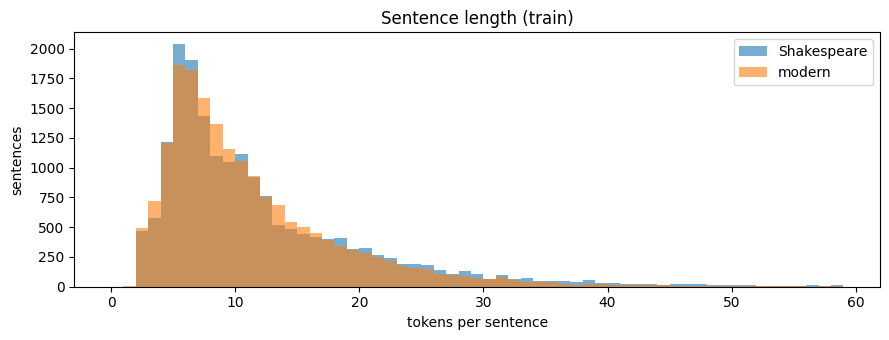

max length: Shakespeare 121, modern 101


In [6]:
src_lens = [len(l.split()) for l in train_src]
tgt_lens = [len(l.split()) for l in train_tgt]

plt.figure(figsize=(9, 3.5))
plt.hist(src_lens, bins=range(0, 60), alpha=0.6, label="Shakespeare")
plt.hist(tgt_lens, bins=range(0, 60), alpha=0.6, label="modern")
plt.xlabel("tokens per sentence")
plt.ylabel("sentences")
plt.legend()
plt.title("Sentence length (train)")
plt.tight_layout()
plt.show()

print("max length: Shakespeare %d, modern %d" % (max(src_lens), max(tgt_lens)))

## 5. Batching — why bucketing matters

Every batch pads to its longest member. Mix a 100-token sentence with a batch of 9-token ones and almost all the compute goes into padding.

`LengthBucketSampler` groups similar lengths together. Measured over a full epoch, the difference is large.

In [7]:
dataset = TranslationDataset(train_src, train_tgt, vocab)

for label, bucket in (("bucketed", True), ("unbucketed", False)):
    loader = make_dataloader(dataset, batch_size=64, bucket=bucket)
    pad = tokens = 0
    for src, _, _ in loader:
        pad += (src == 0).sum().item()
        tokens += src.numel()
    print(f"padding across a full epoch, {label:<11} {pad / tokens:.1%}")

padding across a full epoch, bucketed    9.0%
padding across a full epoch, unbucketed  74.8%


A batch is the same `(src, tgt_in, tgt_out)` triple the toy task used, so `train.py` needs no changes.

In [8]:
loader = make_dataloader(dataset, batch_size=64)
src, tgt_in, tgt_out = next(iter(loader))

print("src    ", tuple(src.shape))
print("tgt_in ", tuple(tgt_in.shape))
print("tgt_out", tuple(tgt_out.shape))
print()
print("src    ", vocab.decode(src[0]))
print("tgt_in ", vocab.decode(tgt_in[0], keep_specials=True))
print("tgt_out", vocab.decode(tgt_out[0]))

src     (64, 10)
tgt_in  (64, 14)
tgt_out (64, 14)

src     I wonder if the lion be to speak .
tgt_in  <sos> I wonder if the lion's going to talk . <pad> <pad> <pad> <pad>
tgt_out I wonder if the lion's going to talk .


## 6. The copy baseline

This is the most important number in the phase. Feed the Shakespeare straight through, unchanged, and score it as if it were a translation.

Because the two sides share most of their words, doing **nothing** already scores respectably. A trained model that lands below this line is worse than useless; one that only just clears it has learned almost nothing. Every BLEU from here gets reported next to it.

In [9]:
print("copy baseline")
print("  valid  BLEU %.2f" % copy_baseline(valid_src, valid_tgt))
print("  test   BLEU %.2f" % copy_baseline(test_src, test_tgt))

copy baseline
  valid  BLEU 15.97
  test   BLEU 19.22


In [10]:
vocab.save(os.path.join(DATA, "vocab.json"))
print("saved vocab.json")

saved vocab.json


## Done

Data loaded, one shared vocabulary of ~10k words built and saved, batches bucketed, and the bar to beat is on the board.

Next: train on this and see whether it clears the baseline.